## **MET (Metabolic Equivalent of Task)**

**Mengapa Menggunakan Data Sintetis (Synthetic Data)?**
Pada tahapan Exploratory Data Analysis (EDA) sebelumnya, ditemukan bahwa dataset publik memiliki nilai korelasi yang sangat rendah (mendekati 0) antara waktu, kecepatan, dan kalori. Hal ini mengindikasikan bahwa data tersebut adalah data *dummy* acak tanpa dasar logika fisika, sehingga tidak ideal untuk melatih model regresi yang akurat.

Sebagai solusinya, saya melakukan **Physics-Informed Synthetic Data Generation** dengan mensimulasikan 5.000 baris data pelari menggunakan standar medis internasional yaitu **MET (Metabolic Equivalent of Task)**.

**Apa itu MET?**

**MET** adalah rasio tingkat metabolisme kerja seseorang relatif terhadap tingkat metabolisme istirahatnya. Secara sederhana, MET mengukur seberapa banyak energi (kalori) yang dibakar oleh tubuh saat melakukan aktivitas fisik tertentu.
* 1 MET = Energi yang dibakar saat duduk diam.
* Berlari santai (8 km/jam) memiliki nilai sekitar **8.3 METs** (tubuh bekerja 8.3 kali lebih keras dari saat istirahat).

**Rumus Pembakaran Kalori Berbasis MET:**
$$Calories = MET \times Weight (kg) \times Time (hours)$$

Dengan menggunakan rumus ini dan menambahkan *noise* acak sebesar $\pm 5\%$ untuk mensimulasikan ketidakakuratan sensor *smartwatch* di dunia nyata, dataset baru ini memiliki pola linear yang sangat kuat, sangat logis secara ilmu olahraga, dan sangat ideal untuk melatih model Machine Learning

In [3]:
import pandas as pd
import numpy as np

# Set seed agar hasilnya selalu sama jika di-run ulang
np.random.seed(42)

# 1. Menentukan jumlah data simulasi
jumlah_data = 5000

# 2. Membuat data profil user secara acak (tapi masuk akal)
berat_badan = np.random.randint(45, 100, jumlah_data) # Berat antara 45 kg - 100 kg
umur = np.random.randint(17, 60, jumlah_data)         # Umur 17 - 60 tahun
tinggi = np.random.randint(150, 190, jumlah_data)     # Tinggi 150 - 190 cm

# 3. Menentukan 3 Kategori Kecepatan (Pace)
# 1 = Santai (8 km/h), 2 = Medium (10.5 km/h), 3 = Cepat (13.5 km/h)
kecepatan_options = [8.0, 10.5, 13.5]
kecepatan_lari = np.random.choice(kecepatan_options, jumlah_data)

# 4. Menentukan nilai MET berdasarkan kecepatan (Standar Medis Olahraga)
# 8.0 km/h = ~8.3 METs
# 10.5 km/h = ~10.5 METs
# 13.5 km/h = ~13.5 METs
met_dict = {8.0: 8.3, 10.5: 10.5, 13.5: 13.5}
met_values = np.array([met_dict[v] for v in kecepatan_lari])

# 5. Membuat target Waktu Lari secara acak (antara 15 menit sampai 120 menit)
waktu_lari_menit = np.random.randint(15, 121, jumlah_data)

# ==========================================
# 6. RUMUS MET
# Rumus: Kalori = MET x Berat(kg) x Waktu(jam)
# ==========================================
waktu_lari_jam = waktu_lari_menit / 60.0
kalori_terbakar_asli = met_values * berat_badan * waktu_lari_jam

# 7. Tambahkan "Noise" (agar data terlihat natural seperti sensor jam tangan asli)
# Kita beri penyimpangan acak sekitar -5% sampai +5%
noise = np.random.uniform(0.95, 1.05, jumlah_data)
kalori_terbakar_final = kalori_terbakar_asli * noise

# 8. Satukan ke dalam DataFrame
df_new = pd.DataFrame({
    'Age': umur,
    'Height(cm)': tinggi,
    'Weight(kg)': berat_badan,
    'Running Speed(km/h)': kecepatan_lari,
    'Calories Burned': np.round(kalori_terbakar_final, 1),
    'Running Time(min)': waktu_lari_menit
})

# 9. Simpan ke folder data
df_new.to_csv('../backend/data/real_running_data.csv', index=False)

print("SIPPP Dataset real_running_data.csv berhasil dibuat!")
print("Dimensi data:", df_new.shape)
display(df_new.head())

SIPPP Dataset real_running_data.csv berhasil dibuat!
Dimensi data: (5000, 6)


,Age,Height(cm),Weight(kg),Running Speed(km/h),Calories Burned,Running Time(min)
0,44,156,83,10.5,580.7,40
1,28,187,96,8.0,1569.2,120
2,54,179,73,10.5,1254.4,100
3,52,154,59,10.5,1187.5,111
4,57,160,87,10.5,1107.2,75


## **Exploratory Data Analysis (EDA)**

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

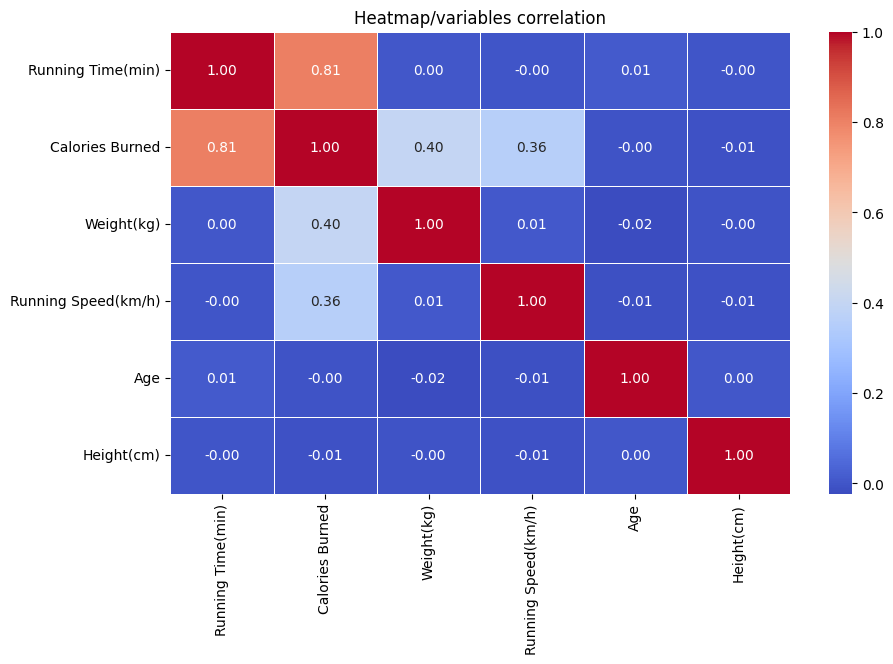


Korelasi fitur terhadap target (Running Time):


,Fitur,Nilai Korelasi
0,Running Time(min),1.000000
1,Calories Burned,0.806388
2,Age,0.010609
3,Weight(kg),0.004370
4,Running Speed(km/h),-0.001509
5,Height(cm),-0.001893


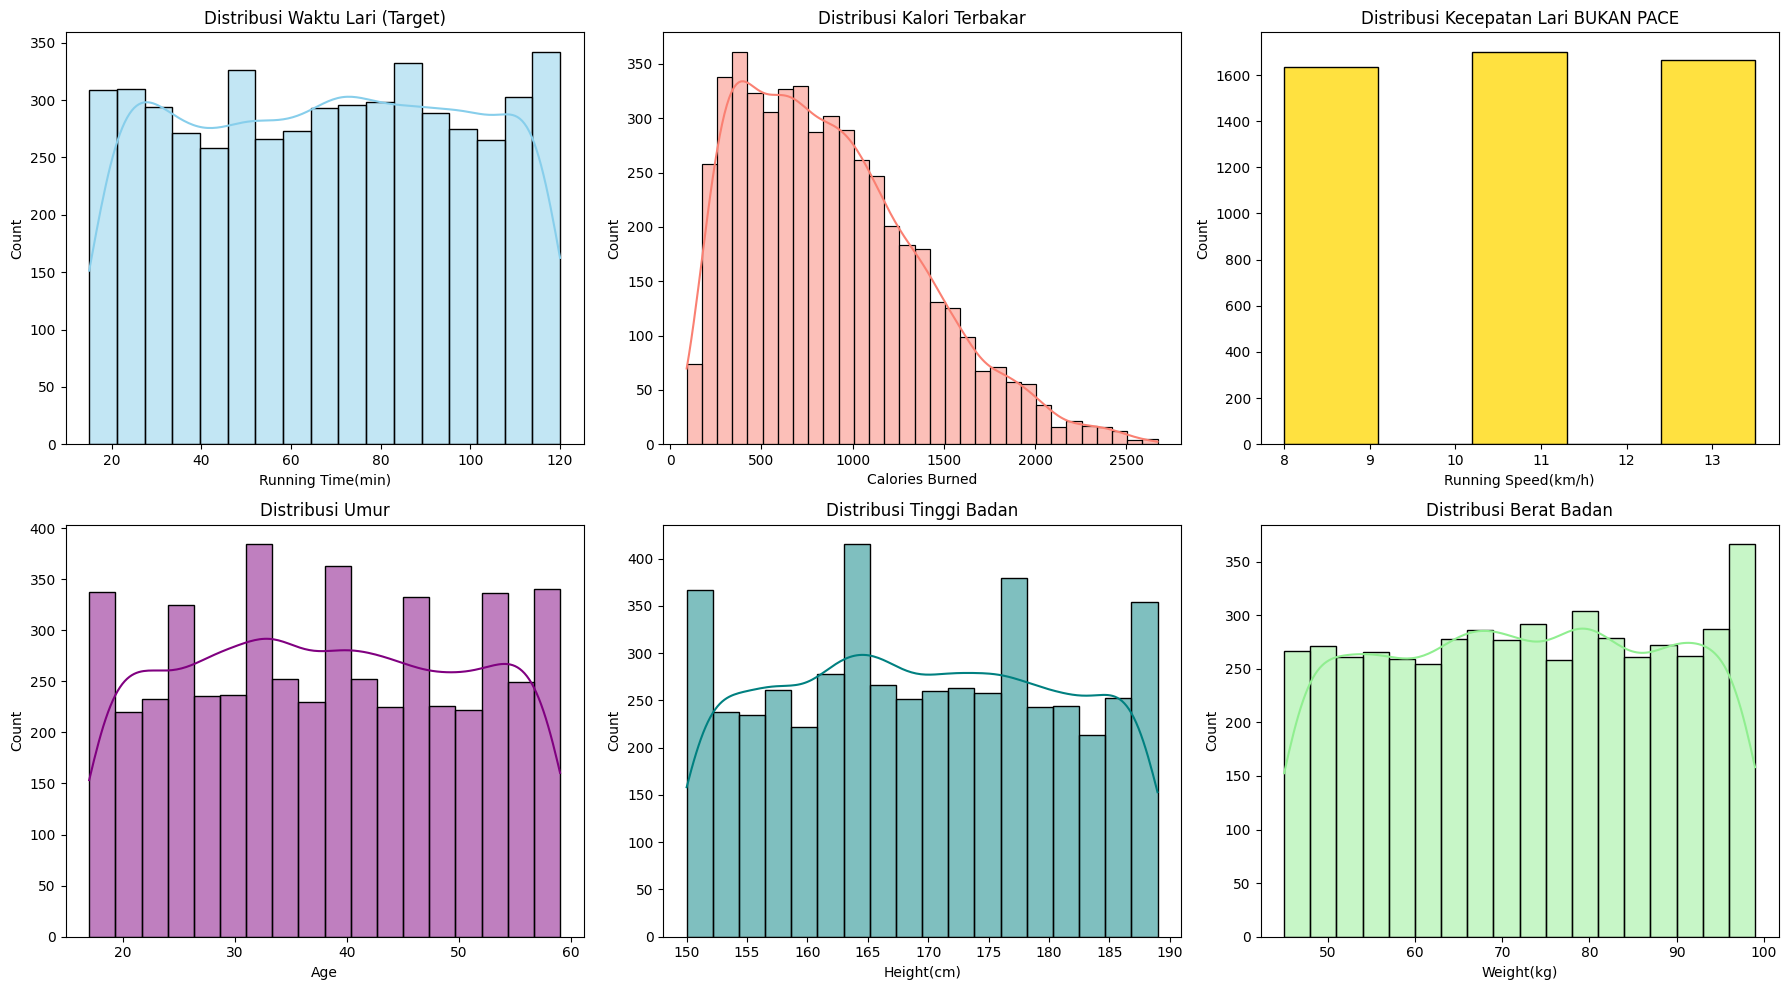

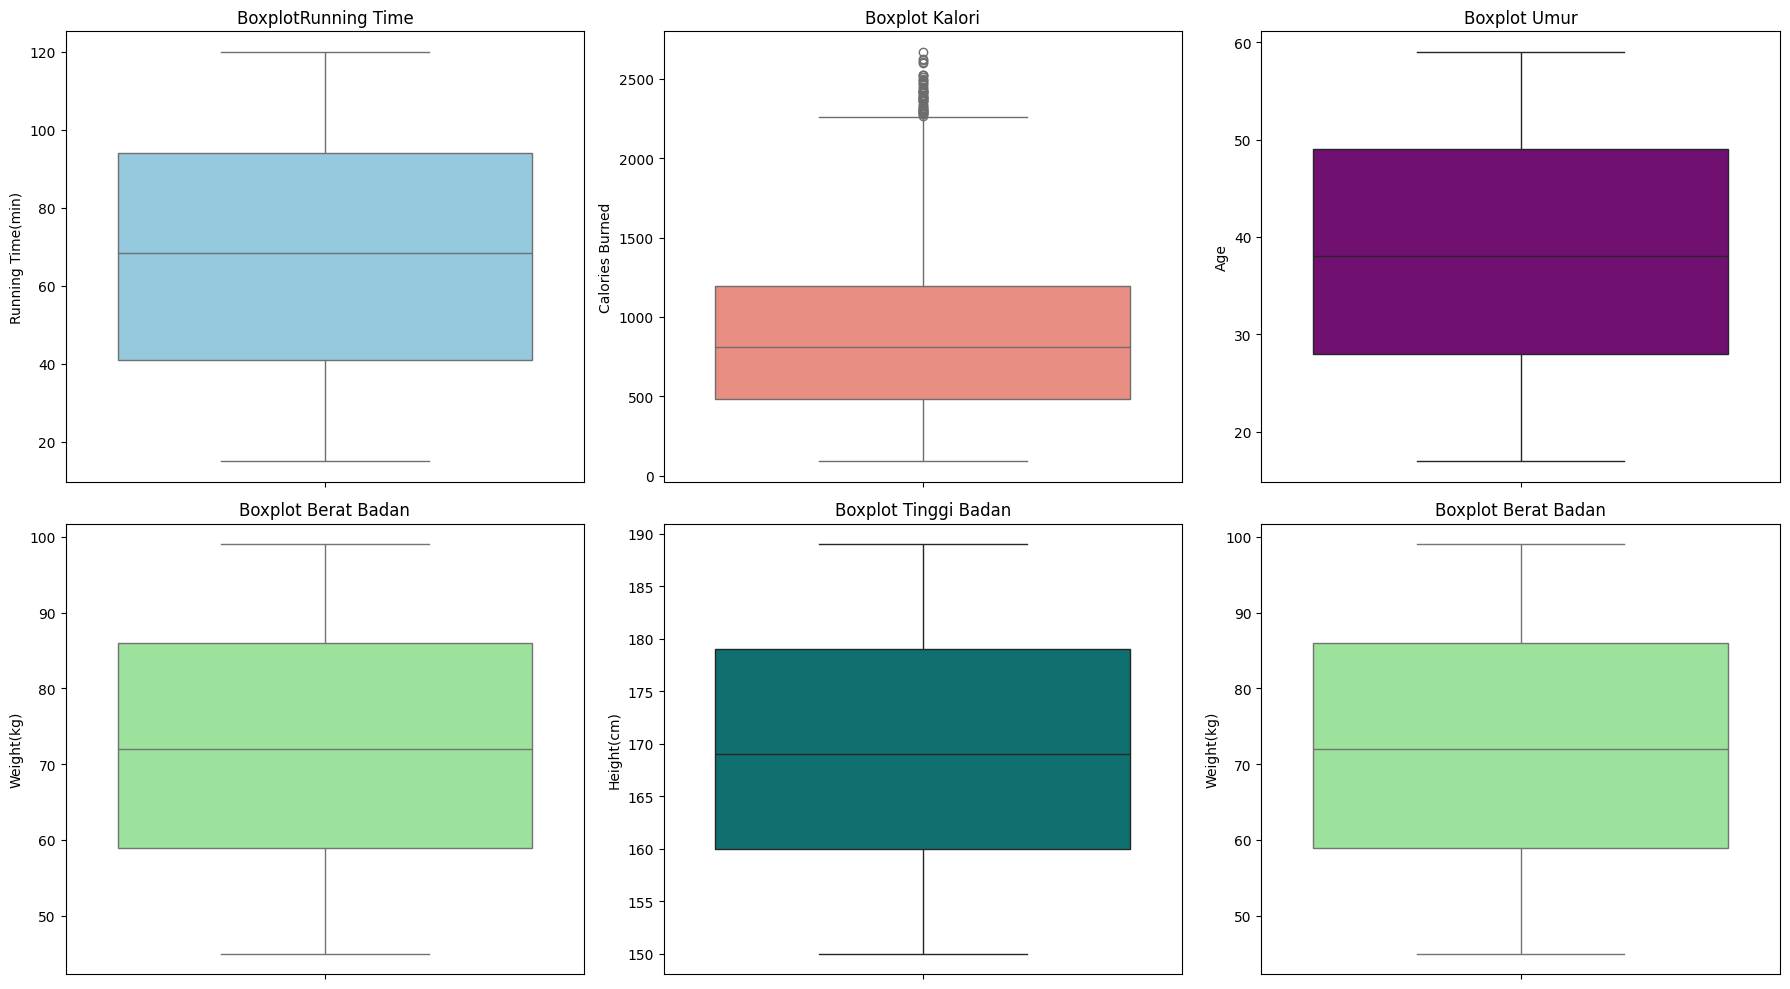

Jumlah outlier Kalori: 53 baris dari 5000 data


,Age,Height(cm),Weight(kg),Running Speed(km/h),Calories Burned,Running Time(min)
4634,55,156,97,13.5,2670.6,118
4728,39,165,98,13.5,2627.0,115
1064,41,164,95,13.5,2618.5,119
2252,42,180,99,13.5,2609.3,116
4655,54,164,97,13.5,2599.3,120
3125,57,163,93,13.5,2523.9,119
3617,44,164,99,13.5,2523.6,110
2858,28,154,96,13.5,2522.6,120
4376,17,165,99,13.5,2511.1,110
2258,30,165,99,13.5,2496.7,107


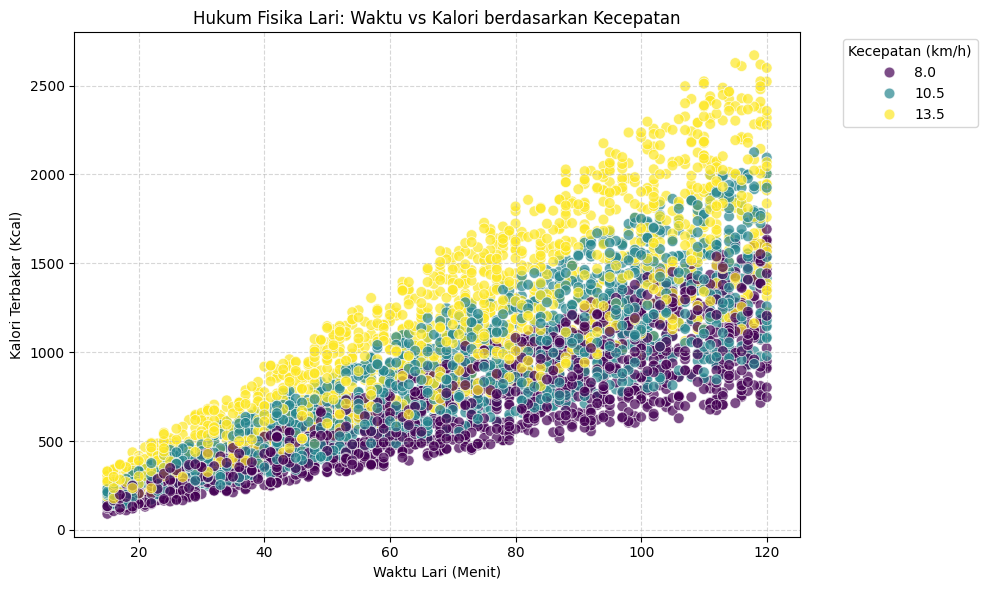

In [5]:
# Load Data 
df_run = pd.read_csv("/Users/josepnat/Developer/Warteg-run/backend/data/real_running_data.csv")

# ============================ HEAT MAP ============================
plt.figure(figsize=(10, 6))

kolom_fokus = ['Running Time(min)', 'Calories Burned', 'Weight(kg)', 'Running Speed(km/h)', 'Age', 'Height(cm)']
df_fokus = df_run[kolom_fokus]

sns.heatmap(df_fokus.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Heatmap/variables correlation")
plt.show()
print("\nKorelasi fitur terhadap target (Running Time):")
korelasi_waktu = df_fokus.corr()['Running Time(min)'].sort_values(ascending=False)

df_korelasi = korelasi_waktu.reset_index()
df_korelasi.columns = ['Fitur', 'Nilai Korelasi']
display(df_korelasi)

# ========================================================================= UNIVARIATE =========================================================================

# ============================ HISTOGRAM ============================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()


# 1. Target: Waktu Lari
sns.histplot(df_run['Running Time(min)'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribusi Waktu Lari (Target)')

# 2. Fitur Utama: Kalori
sns.histplot(df_run['Calories Burned'], kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribusi Kalori Terbakar')

# 3. Fitur Utama: Kecepatan
sns.histplot(df_run['Running Speed(km/h)'], kde=False, ax=axes[2], color='gold', bins=5)
axes[2].set_title('Distribusi Kecepatan Lari BUKAN PACE')

# 4. Fitur Demografi: Umur
sns.histplot(df_run['Age'], kde=True, ax=axes[3], color='purple')
axes[3].set_title('Distribusi Umur')

# 5. Fitur Demografi: Tinggi Badan
sns.histplot(df_run['Height(cm)'], kde=True, ax=axes[4], color='teal')
axes[4].set_title('Distribusi Tinggi Badan')

# 6. Fitur Demografi: Berat Badan
sns.histplot(df_run['Weight(kg)'], kde=True, ax=axes[5], color='lightgreen')
axes[5].set_title('Distribusi Berat Badan')

plt.tight_layout()
plt.show()

# ============================ BOX PLOT ============================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

sns.boxplot(y=df_run['Running Time(min)'], ax=axes[0], color='skyblue')
axes[0].set_title('BoxplotRunning Time')

sns.boxplot(y=df_run['Calories Burned'], ax=axes[1], color='salmon')
axes[1].set_title('Boxplot Kalori')

sns.boxplot(y=df_run['Age'], ax=axes[2], color='purple')
axes[2].set_title('Boxplot Umur')

sns.boxplot(y=df_run['Weight(kg)'], ax=axes[3], color='lightgreen')
axes[3].set_title('Boxplot Berat Badan')

sns.boxplot(y=df_run['Height(cm)'], ax=axes[4], color='teal')
axes[4].set_title('Boxplot Tinggi Badan')

sns.boxplot(y=df_run['Weight(kg)'], ax=axes[5], color='lightgreen')
axes[5].set_title('Boxplot Berat Badan')

plt.tight_layout()
plt.show()

Q1 = df_run["Calories Burned"].quantile(0.25)
Q3 = df_run["Calories Burned"].quantile(0.75)
IQR = Q3 - Q1
Batas_Atas = Q3 + 1.5 * IQR

outliers = df_run[df_run['Calories Burned'] > Batas_Atas]
print(f"Jumlah outlier Kalori: {outliers.shape[0]} baris dari 5000 data")
display(outliers.sort_values(by='Calories Burned', ascending=False).head(10))

# ========================================================================= MULTIVARIATE =========================================================================

# ============================ SCATTER PLOT ============================
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_run, 
    x='Running Time(min)', 
    y='Calories Burned', 
    hue='Running Speed(km/h)', 
    palette='viridis',         
    alpha=0.7,                 
    s=60                       
)

plt.title("Hukum Fisika Lari: Waktu vs Kalori berdasarkan Kecepatan")
plt.xlabel("Waktu Lari (Menit)")
plt.ylabel("Kalori Terbakar (Kcal)")
plt.legend(title="Kecepatan (km/h)", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

**Feature Selection (Menentukan variable X dan y)**

In [8]:
# Input: Kalori, Berat, Kecepatan, Umur, Tinggi
X = df_run[['Calories Burned', 'Weight(kg)', 'Running Speed(km/h)', 'Age', 'Height(cm)']]
# Output: Waktu Lari
y = df_run['Running Time(min)']

**Data Preprocessing**

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ============================ Splitting 8:2 ============================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ============================ Scaling (Menyamakan skala angka) ============================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Model Comparison**

In [19]:
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import joblib
import os

models = {
    "Linear Regression":LinearRegression(),
    "Random Forest":RandomForestRegressor(n_estimators=100, random_state=42)
}

print("Hasil adu:")
hasil_evaluasi = []
best_model = None
best_model_name = ""
best_mae = float("inf") # inf = infinite


Hasil adu:


**Evaluation**

--- Tabel Evaluasi Model Regresi ---


,Model,MAE (Menit),MSE,RMSE (Menit),Akurasi (R2)
1,Random Forest,2.02,6.81,2.61,0.9927
0,Linear Regression,6.97,84.72,9.20,0.9095


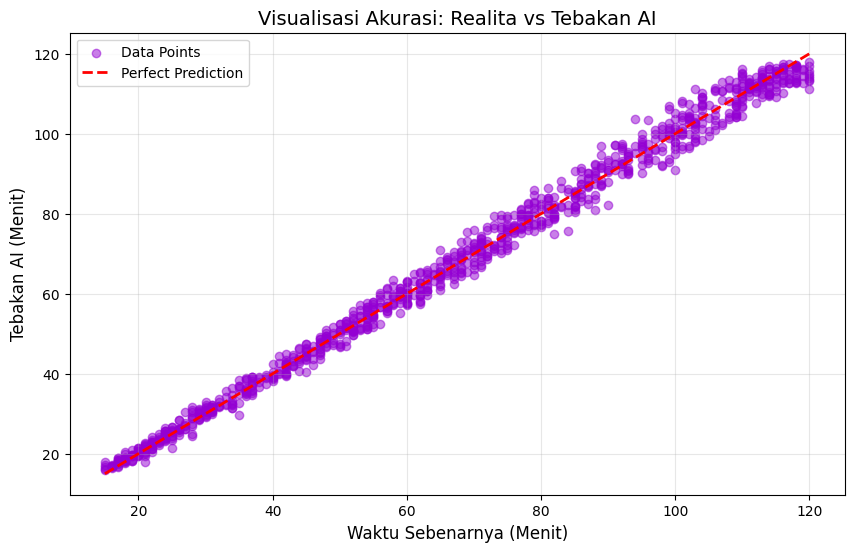

/var/folders/1q/8jq91msj3j757kq0m0p6h24r0000gn/T/ipykernel_1999/673936259.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=df_feat, palette='magma')


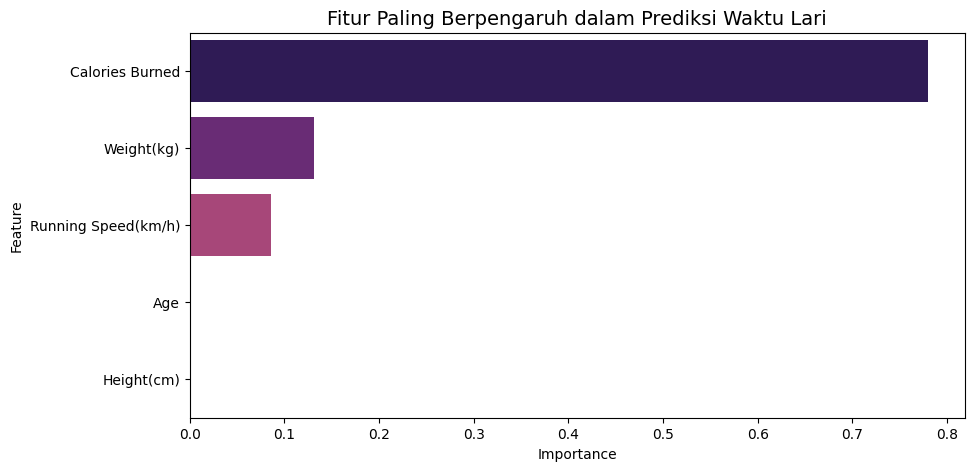

In [21]:

# ============================ EVALUASI METRIK MENDALAM (Regression Style) ============================

hasil_lengkap = []

for name, model in models.items():
    # Proses Belajar (WAJIB agar tidak NotFittedError)
    model.fit(X_train_scaled, y_train)
    
    # Proses Ujian
    preds = model.predict(X_test_scaled)
    
    # Hitung Metrik
    mae = mean_absolute_error(y_test, preds)
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, preds)
    
    hasil_lengkap.append({
        "Model": name,
        "MAE (Menit)": round(mae, 2),
        "MSE": round(mse, 2),
        "RMSE (Menit)": round(rmse, 2),
        "Akurasi (R2)": round(r2, 4)
    })

# ============================ Tabel Evaluasi ============================
df_eval = pd.DataFrame(hasil_lengkap).sort_values(by="Akurasi (R2)", ascending=False)
print("--- Tabel Evaluasi Model Regresi ---")
display(df_eval)

# ============================ VISUALISASI: ACTUAL VS PREDICTED ============================

best_model = models["Random Forest"]
best_preds = best_model.predict(X_test_scaled)

plt.figure(figsize=(10, 6))
plt.scatter(y_test, best_preds, alpha=0.5, color='darkviolet', label='Data Points')
# Garis diagonal (Garis prediksi sempurna)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')

plt.title('Visualisasi Akurasi: Realita vs Tebakan AI', fontsize=14)
plt.xlabel('Waktu Sebenarnya (Menit)', fontsize=12)
plt.ylabel('Tebakan AI (Menit)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


# ============================ FEATURE IMPORTANCE (Analisis Pola) ============================

importances = best_model.feature_importances_
feat_names = X.columns
df_feat = pd.DataFrame({'Feature': feat_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x='Importance', y='Feature', data=df_feat, palette='magma')
plt.title('Fitur Paling Berpengaruh dalam Prediksi Waktu Lari', fontsize=14)
plt.show()

## **Export Model**

In [22]:
import joblib
import os

target_dir = "/Users/josepnat/Developer/Warteg-run/backend/models/"

# Buat foldernya kalau belum ada
os.makedirs(target_dir, exist_ok=True)

# Simpan paksa
joblib.dump(best_model, os.path.join(target_dir, 'runner_model.pkl'))
joblib.dump(scaler, os.path.join(target_dir, 'scaler.pkl'))

print(f"MANTABBBB! File sudah mendarat aman di: {target_dir}")

MANTABBBB! File sudah mendarat aman di: /Users/josepnat/Developer/Warteg-run/backend/models/
